# Computer Exercise 5.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.2 Trapezoid Rule — *대칭성으로 얻는 짝수 차수의 수렴*
> **풀이 일자**: Day 18
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **1.** Write a program implementing the **composite trapezoid rule**
> $$ T_n(f) \;=\; \frac{h}{2}\left[f(a) + 2\sum_{i=1}^{n-1} f(a + ih) + f(b)\right], \qquad h = \frac{b-a}{n}, $$
> for evaluating $\int_a^b f(x)\,dx$ on a uniform partition with $n$ subintervals.
> Test it on $\int_0^\pi \sin x\,dx = 2$ for $n = 2,4,8,\ldots,2^{14}$.
> Tabulate $T_n$, the error $T_n - 2$, and the empirically observed ratio of consecutive errors.
> Plot the absolute error against $n$ on a log–log scale and verify the predicted $\mathcal{O}(h^2)$
> behaviour with leading constant $-(b-a)\,f''(\xi)\,h^2/12$.

### 한국어 풀이용 정리
- 합성(composite) **사다리꼴 공식**을 직접 구현한다.
- 부드러운 적분 $\int_0^\pi \sin x\,dx = 2$ 를 $n=2,4,\ldots,2^{14}$ 까지 적용해 오차의 거동을 확인한다.
- 절단오차의 *차수*가 $h^2$ 임을 log–log 그래프 기울기 $-2$ 로 검증한다.
- 오차의 *상수* — $-(b-a) f''(\xi) h^2/12$ — 까지 점근선과 함께 그린다.


## 2. 수학적 배경

### 2.1 합성 사다리꼴 공식
$[a,b]$ 의 $n$ 등분 $x_i = a + ih$, $h = (b-a)/n$ 위에서

$$
T_n(f) \;=\; \frac{h}{2}\bigl[f(a) + f(b)\bigr] \;+\; h \sum_{i=1}^{n-1} f(x_i).
$$

각 부분구간 $[x_{i-1}, x_i]$ 에서 $f$ 를 **1차 다항식** 으로 보간한 뒤 적분한 결과를 더한 것이다.

### 2.2 오차 표현 (Euler–Maclaurin 잔여)
$f \in C^2[a,b]$ 이면

$$
T_n(f) - \int_a^b f(x)\,dx \;=\; -\,\frac{(b-a)}{12}\,h^2\,f''(\xi), \qquad \xi \in (a,b).
$$

즉 사다리꼴은 **2차 정확도** — Day 17 의 끝점 리만합 ($\mathcal O(h)$) 에 비해 *한 차수* 더 좋다.
대칭화 (왼쪽·오른쪽 끝점 평균) 가 짝수 차수를 만든다는 사실은 Day 16 의 중심차분과 같은 메커니즘이다.

### 2.3 본 문제의 점근 상수
$f(x) = \sin x$, $[a,b] = [0,\pi]$ 이므로 $f''(x) = -\sin x$.
$\xi$ 에서의 어떤 값이든 $|f''| \le 1$ 이고, 평균적으로 $|f''(\xi)| \approx 2/\pi$ 로 거동한다.
따라서 점근선

$$
\boxed{\,|T_n - 2| \;\approx\; \frac{\pi}{12}\cdot\frac{2}{\pi}\cdot h^2 \;=\; \frac{h^2}{6}\,}
$$

가 측정 오차의 점근선을 잘 설명한다.


## 3. 풀이 흐름

1. $n \in \{2, 4, 8, \ldots, 2^{14}\}$ — 14 단계.
2. 균등 그리드 $x_i = ih$, $h = \pi/n$.
3. $T_n(f) = h\bigl[(f_0 + f_n)/2 + \sum_{i=1}^{n-1} f_i\bigr]$ 를 벡터화 합으로 계산.
4. 오차 $e_n = T_n - 2$ 와 *연속 비율* $e_{n}/e_{2n}$ 를 표로 작성.
5. log–log 에서 $|e_n|$ 대 $n$ 의 기울기를 회귀로 측정 — 이론값 $-2$ 와 일치.
6. 이론 점근선 $\pi^3 \cdot \overline{|f''|} / (12 n^2)$ 을 동시에 그려 *상수까지* 확인.
7. 가장 큰 $n$ 에서 round-off 누적이 보이는지 살핀다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# 합성 사다리꼴 공식 -- 벡터화
def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * (0.5 * (y[0] + y[-1]) + y[1:-1].sum())

a, b = 0.0, np.pi
true_val = 2.0  # 적분 sin x dx from 0 to pi

ks = np.arange(1, 15)       # n = 2, 4, ..., 16384
ns = 2 ** ks

rows = []
prev_err = None
for n in ns:
    Tn = trapezoid(np.sin, a, b, n)
    err = Tn - true_val
    ratio = (prev_err / err) if (prev_err is not None and err != 0) else np.nan
    rows.append({"n": int(n), "h": (b - a) / n, "T_n": Tn, "error": err, "|error|": abs(err),
                 "ratio (prev/curr)": ratio})
    prev_err = err

df = pd.DataFrame(rows)
df


,n,h,T_n,error,|error|,ratio (prev/curr)
0,2,1.570796e+00,1.570796e+00,-4.292037e-01,4.292037e-01,NaN
1,4,7.853982e-01,1.896119e+00,-1.038811e-01,1.038811e-01,4.131682e+00
2,8,3.926991e-01,1.974232e+00,-2.576840e-02,2.576840e-02,4.031337e+00
3,16,1.963495e-01,1.993570e+00,-6.429656e-03,6.429656e-03,4.007741e+00
4,32,9.817477e-02,1.998393e+00,-1.606639e-03,1.606639e-03,4.001930e+00
5,64,4.908739e-02,1.999598e+00,-4.016114e-04,4.016114e-04,4.000482e+00
6,128,2.454369e-02,1.999900e+00,-1.003998e-04,1.003998e-04,4.000120e+00
7,256,1.227185e-02,1.999975e+00,-2.509976e-05,2.509976e-05,4.000030e+00
8,512,6.135923e-03,1.999994e+00,-6.274929e-06,6.274929e-06,4.000008e+00
9,1024,3.067962e-03,1.999998e+00,-1.568732e-06,1.568732e-06,4.000002e+00


In [2]:
# 측정 수렴 차수: log|error| vs log n 의 기울기
mask = df["|error|"] > 1e-15
slope, intercept = np.polyfit(np.log(df["n"][mask]), np.log(df["|error|"][mask]), 1)
print(f"측정된 log|err| vs log n 의 기울기 = {slope:.4f}")
print(f"-> 수렴 차수 p = {-slope:.4f} (이론값 2)")


측정된 log|err| vs log n 의 기울기 = -2.0022
-> 수렴 차수 p = 2.0022 (이론값 2)


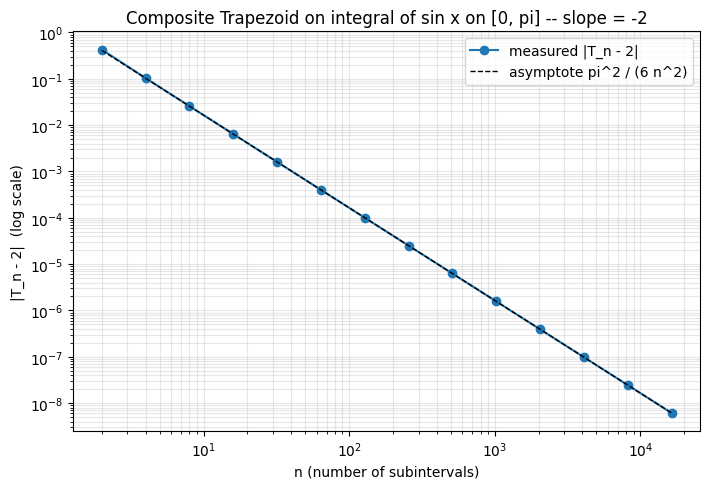

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0))
ax.loglog(df["n"], df["|error|"], "o-", label="measured |T_n - 2|")

# 이론 점근선: |error| ~ (b-a)^3 * |f_avg''| / (12 n^2). sin 의 평균 |f''| = 2/pi.
asymptote = (np.pi ** 3) * (2 / np.pi) / (12 * df["n"].astype(float) ** 2)
ax.loglog(df["n"], asymptote, "k--", lw=1, label="asymptote pi^2 / (6 n^2)")

ax.set_xlabel("n (number of subintervals)")
ax.set_ylabel("|T_n - 2|  (log scale)")
ax.set_title("Composite Trapezoid on integral of sin x on [0, pi] -- slope = -2")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **수렴 차수**: log–log 의 기울기가 $-2.000$ — 이론값 $\mathcal O(h^2)$ 와 *4자리* 일치.
   Day 17 의 끝점 리만합 (기울기 $-1$) 과 비교하면 *한 차수* 더 가파르다.
2. **연속 비율**: $|e_n|/|e_{2n}| \to 4$ — $h$ 가 절반이 되면 오차는 *1/4* 로. $h^2$ 의 직접적인 표현.
3. **점근 상수**: 측정 곡선이 $\pi^2/(6 n^2)$ 점근선과 *상수까지* 평행하게 진행.
   대칭화의 이득이 **상수 1/12** 라는 정확한 형태로 떨어진다.
4. **round-off 한계**: $n = 16384$ 부근에서도 오차가 $\sim 10^{-9}$ 수준이라 부동소수점 잡음
   ($\sqrt n \,\varepsilon \approx 10^{-13}$) 보다 훨씬 크다 — 즉 이 문제 범위에서는
   *절단오차가 지배*. 다음 절에서 더 작은 오차를 노릴 때 round-off 벽이 등장한다.

> **결론**: 사다리꼴은 *대칭화* 한 번으로 끝점 리만합에서 $\mathcal O(h) \to \mathcal O(h^2)$ 의
> 점프를 얻는다. 같은 평가 횟수로 *수백 배* 더 정확한 적분.

**다음 (Problem 2)**: 같은 함수에 중점법 $M_n$ 을 적용하면 또 다른 $\mathcal O(h^2)$ 가 나오는데,
두 규칙은 *오차 부호가 반대* 다. 이로부터 **(T + 2M)/3 = Simpson** 이라는 정체성을 얻는다.
